# Visualize 2nd level results (generated via SPM)

* do cluster thresholding
* plot stat map with z-values but masked by cluster thresholded map --> paper
* report cluster table  --> paper
* interaactive plotting

In [3]:
import os.path  as op
from os import listdir
import matplotlib
from matplotlib import pyplot as plt
import nilearn
import nibabel as nib
import numpy as np
import nilearn.plotting as nipl 
import nilearn.image as niim
import matplotlib as mpl

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk' ## fucking.... Vhat-1 mPFC cluster survives only in SPM saves locally (though should be the same, no idea why...)
bids_folder_local = '/Users/mrenke/data/ds-stressrisk'

subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [4]:
def get_2ndlevel_spm(model, version, con, bids_folder, specification='con', num=1, ses='_ses-1'):
    spm_file = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_{specification}_2ndlevels{ses}',f'2ndlevel_{model}-{version}_{con}',f'spmT_000{num}.nii')
    spm = nib.load(spm_file)
    return spm


#/Users/mrenke/data/ds-stressrisk/derivatives/spm/Vhat-1_con_2ndlevels_ses-1/2ndlevel_Vhat-1_v1/con_0001.nii

In [5]:
# plot anat and then func
model = 'Vhat'#'EU' #
version = 1
contrast = 'v2'
spm = get_2ndlevel_spm(model, version, contrast, bids_folder, ses='_ses-1')


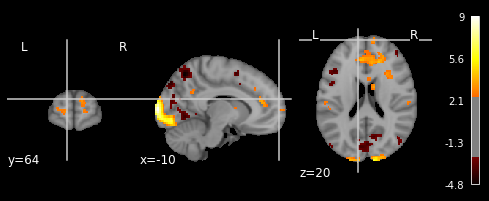

In [6]:

anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

coords = [-10, 64, 20]
display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
display.add_overlay(spm, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['hot'])


In [7]:
from scipy.stats import norm
p_val = 0.001
p001_uncorrected = norm.isf(p_val) # Inverse survival function (inverse of sf)., 3.09, associated T-value

from nilearn.glm import cluster_level_inference
spm_cluster_level_inf = cluster_level_inference(spm, threshold=p001_uncorrected, alpha=0.05) # threshold=[3, 4, 5]

# mask corrected
mpfc_mask_file = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/surface_masks/mask_MarsAtlas_mPFC_MNI.nii'
mpfc_mask = nib.load(mpfc_mask_file)
spm_cluster_level_masked = cluster_level_inference(spm, threshold=[3, 4, 5], alpha=0.05, mask_img=mpfc_mask)

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


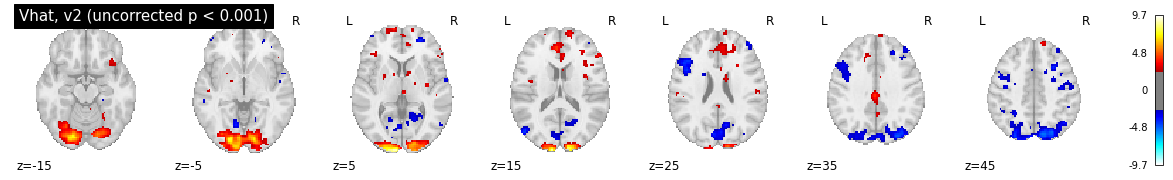

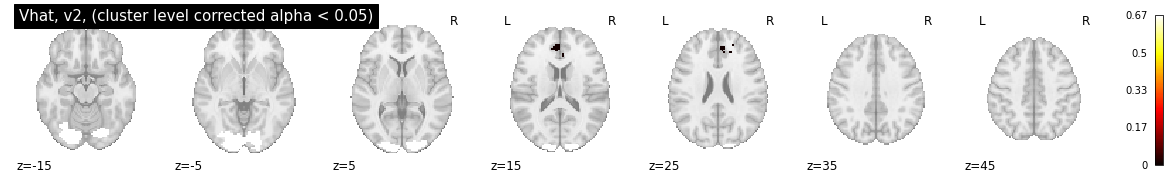

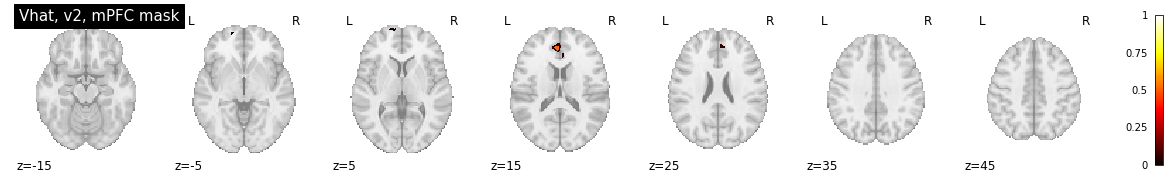

In [9]:
from nilearn import plotting

from nilearn import plotting
cut_coords = range(-15,50,10)
plotting.plot_stat_map(spm,threshold=2.5, display_mode="z", cut_coords = cut_coords,colorbar=True,
    title=f"{model}, {contrast} (uncorrected p < 0.001)",)
plotting.plot_stat_map(spm_cluster_level_inf, threshold=0.0, display_mode="z",cut_coords = cut_coords, colorbar=True,
    title=f"{model}, {contrast}, (cluster level corrected alpha < 0.05)")
plotting.plot_stat_map(spm_cluster_level_masked, threshold=0.0, display_mode="z",cut_coords = cut_coords,colorbar=True,
    title=f"{model}, {contrast}, mPFC mask",)

plotting.show()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_93088/3703412389.py:1: DeprecationWarning: get_data() is deprecated in favor of get_fdata(), which has a more predictable return type. To obtain get_data() behavior going forward, use numpy.asanyarray(img.dataobj).

* deprecated from version: 3.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 5.0
  cluster_masekd_z_vals = spm.get_data().copy()  #weird, getting data and fdata different@!


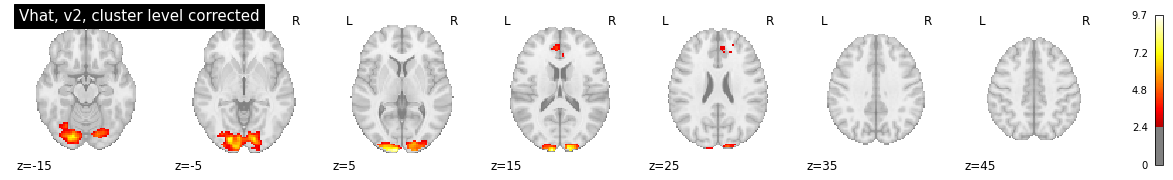

In [10]:
cluster_masekd_z_vals = spm.get_data().copy()  #weird, getting data and fdata different@!
cluster_masekd_z_vals[spm_cluster_level_inf.get_fdata() < 0.0001] = 0

# Create a new NIfTI image with the modified data
cluster_masekd_z_vals_img = nib.Nifti1Image(cluster_masekd_z_vals, spm.affine, spm.header)
plotting.plot_stat_map(cluster_masekd_z_vals_img, threshold=2.5, display_mode="z",cut_coords = cut_coords,colorbar=True,
    title=f"{model}, {contrast}, cluster level corrected",)
plt.savefig(op.join(bids_folder_local, 'plots_and_ims','glm_spms',f'glm_{model}_{contrast}.png'))

In [11]:
from nilearn import reporting

report_table = reporting.get_clusters_table(cluster_masekd_z_vals_img,stat_threshold = 0, cluster_threshold=0, 
                             two_sided=False, min_distance=8.0)
report_table.to_csv(op.join(bids_folder_local, 'interim_sum_data',f'glm_table_{model}_{contrast}.csv'))
report_table

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-11.5,-102.5,8.5,9.652147,27262
1,1a,-19.0,-85.0,-9.5,8.121943,
2,1b,11.0,-100.0,14.5,7.953162,
3,1c,-11.5,-92.5,-9.5,7.208487,
4,2,-4.0,40.0,17.5,4.870433,2025
5,2a,18.5,35.0,20.5,4.253094,
6,2b,8.5,32.5,20.5,3.803305,
7,2c,6.0,45.0,26.5,3.499158,


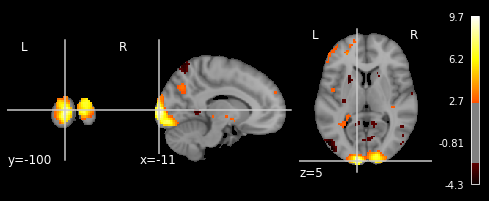

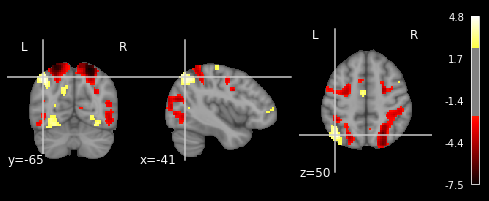

In [172]:
anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

for cluster_id in range(1,3):
    coords = report_table[report_table['Cluster ID']==cluster_id][['X','Y','Z']].values.tolist()[0]
    display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
    display.add_overlay(spm, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['hot'])   

In [ ]:
#interactive viewing
from nilearn import plotting, datasets
html_view = plotting.view_img(spm, threshold=2, vmax=4,
                              cut_coords=[-42, -16, 52],
                              title=contrast)

html_view.open_in_browser()